In [241]:
from pathlib import Path
import re
import pandas as pd

#transcript_path = Path("/Users/nourahmed/Arabic-NLP-System/Transcripts/الأخطبوط  الدحيح.txt")
#qa_path = Path("/Users/nourahmed/Arabic-NLP-System/QA/8rcY34IA-6I_QA.csv")
transcript_path = Path("/Users/nourahmed/Arabic-NLP-System/Transcripts/الساموراي  الدحيح.txt")
qa_path = Path("/Users/nourahmed/Arabic-NLP-System/QA/3AwL93uolIA_QA.csv")
#transcript_path = Path("/Users/nourahmed/Arabic-NLP-System/Transcripts/كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.txt")
#qa_path = Path("/Users/nourahmed/Arabic-NLP-System/QA/z2NGnjXG5uQ_QA.csv")
# Read raw transcript lines
with open(transcript_path, "r", encoding="utf-8") as f:
    transcript_lines_raw = f.readlines()

print("Transcript lines:", len(transcript_lines_raw))
print("First 5 raw lines:")
for l in transcript_lines_raw[:5]:
    print(l.rstrip())

# Read QA
qa = pd.read_csv(qa_path)
print("\nQA shape:", qa.shape)
print("QA columns:", qa.columns.tolist())
qa.head()
# are all answers available in the transcript?
qa['answer_in_transcript'] = qa['answer'].apply(lambda ans: any(ans in line for line in transcript_lines_raw))
print("\nAnswer presence in transcript:")
print(qa['answer_in_transcript'].value_counts())
def audit_transcript_noise(lines):
    report = {
        "short_lines": [],     # Potential broken words or artifacts
        "placeholder_tags": [], # [Music], [Laughter], etc.
        "repetitive_chars": []  # Long stretches of ........ or آآآآآ
    }
    
    for i, line in enumerate(lines):
        # Detect very short lines (1-3 chars)
        if 0 < len(line) <= 3:
            report["short_lines"].append((i, line))
            
        # Detect placeholders inside brackets
        placeholders = re.findall(r'\[.*?\]|\(.*?\)', line)
        if placeholders:
            report["placeholder_tags"].extend(placeholders)
            
        # Detect high-repetition noise
        if re.search(r'(.)\1{4,}', line):
            report["repetitive_chars"].append((i, line))
            
    return report

# Run the audit on your timestamp-removed lines
noise_report = audit_transcript_noise(transcript_lines_raw)
print(f"Found {len(noise_report['short_lines'])} suspicious short lines.")
print(f"Unique placeholders found: {set(noise_report['placeholder_tags'])}")
print(f"Found {len(noise_report['repetitive_chars'])} lines with repetitive characters.")

Transcript lines: 954
First 5 raw lines:
0.167: منذ زمنٍ بعيد،
2.6: في أرضٍ ليست ببعيدة...
6.818: كان هُناك طفلٌ مصريٌ سمين،
10.204: يحلم بأن يكون أول ساموراي مصري في العالم.
17.745: كَبُر الطفل،

QA shape: (300, 6)
QA columns: ['video_id', 'video_title', 'question_id', 'question', 'answer', 'difficulty']

Answer presence in transcript:
answer_in_transcript
True    300
Name: count, dtype: int64
Found 0 suspicious short lines.
Unique placeholders found: {'(هاكاتا)', '(ساتسوما)', '(لينكدإن)', '(إيدو)', '(أبو حميد)', '(شوجونية)', '(كونان)', '(ميجي)'}
Found 0 lines with repetitive characters.


In [242]:
def strip_timestamp(line: str) -> str:
    # Pattern 1: Handles 0.389: or 12.144:
    # Pattern 2: Handles 00:00:00 or 12:30
    # Both followed by an optional colon and space
    timestamp_pattern = r"^(\d+[\.:]\d+([\.:]\d+)?[:]?)\s*"
    
    return re.sub(timestamp_pattern, "", line).strip()

# Apply and drop empty lines
transcript_no_ts_lines = [strip_timestamp(l) for l in transcript_lines_raw if strip_timestamp(l)]

print("First 5 lines (Truly Cleaned):")
for l in transcript_no_ts_lines[:5]:
    print(l)

First 5 lines (Truly Cleaned):
منذ زمنٍ بعيد،
في أرضٍ ليست ببعيدة...
كان هُناك طفلٌ مصريٌ سمين،
يحلم بأن يكون أول ساموراي مصري في العالم.
كَبُر الطفل،


/var/folders/mq/sq5nd49s25j3hzrx4b1tf_bc0000gn/T/ipykernel_82174/943651042.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_qa, x='difficulty', palette='viridis', order=['Easy', 'Medium', 'Hard'])


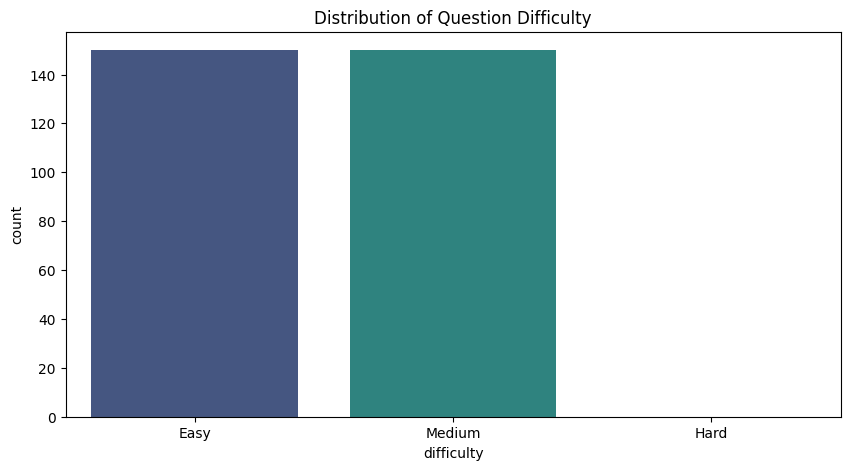

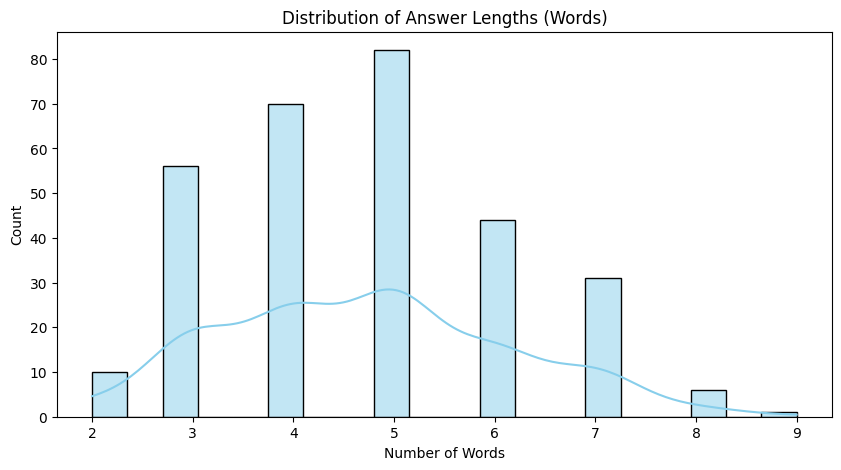

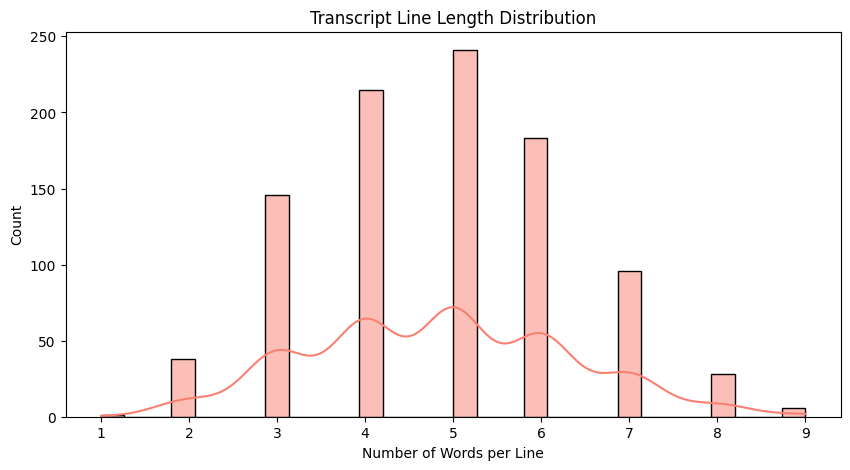

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distributions(df_qa, transcript_lines):
    # 1. Question Difficulty Distribution
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_qa, x='difficulty', palette='viridis', order=['Easy', 'Medium', 'Hard'])
    plt.title('Distribution of Question Difficulty')
    plt.show()

    # 2. Answer Length Distribution (Word Count)
    df_qa['answer_length'] = df_qa['answer'].str.split().str.len()
    plt.figure(figsize=(10, 5))
    sns.histplot(df_qa['answer_length'], bins=20, kde=True, color='skyblue')
    plt.title('Distribution of Answer Lengths (Words)')
    plt.xlabel('Number of Words')
    plt.show()

    # 3. Transcript Line Length Distribution
    line_lengths = [len(line.split()) for line in transcript_lines]
    plt.figure(figsize=(10, 5))
    sns.histplot(line_lengths, bins=30, kde=True, color='salmon')
    plt.title('Transcript Line Length Distribution')
    plt.xlabel('Number of Words per Line')
    plt.show()

# Run the plots
plot_distributions(qa, transcript_no_ts_lines)

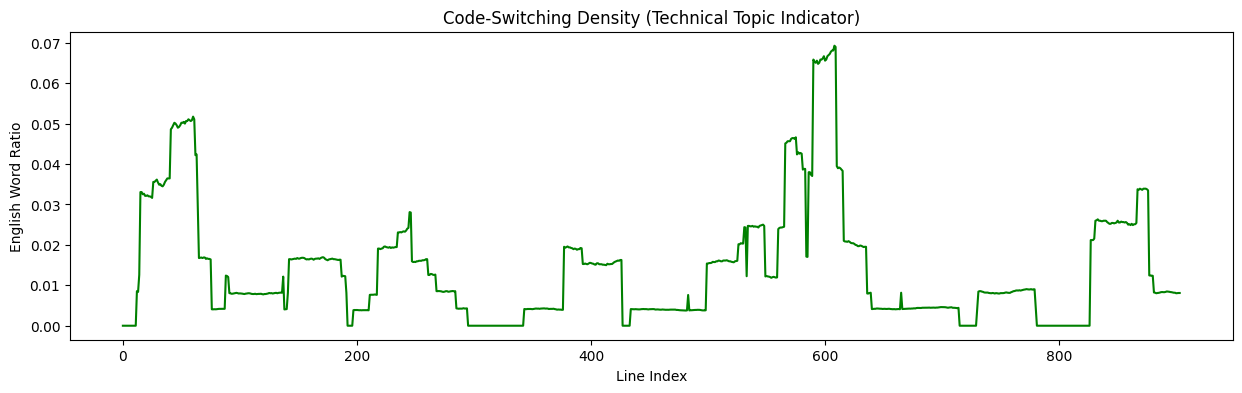

In [244]:
def plot_topic_flow(lines, window_size=50):
    """Calculates English word density over a sliding window to find technical topics."""
    densities = []
    for i in range(len(lines) - window_size):
        chunk = " ".join(lines[i : i + window_size])
        words = chunk.split()
        english_stopwords = {'The', 'of', 'and', 'in', 'to', 'a', 'is'}
        eng_words = re.findall(r'[A-Za-z]+', chunk)
        found_titles = [w for w in eng_words if w not in english_stopwords]
        eng_count = sum(found_titles.count(w) for w in found_titles)
        densities.append(eng_count / len(words) if len(words) > 0 else 0)
    
    plt.figure(figsize=(15, 4))
    plt.plot(densities, color='green')
    plt.title('Code-Switching Density (Technical Topic Indicator)')
    plt.xlabel('Line Index')
    plt.ylabel('English Word Ratio')
    plt.show()

plot_topic_flow(transcript_no_ts_lines)

In [245]:
from collections import Counter
def analyze_entities_and_refs(lines):
    text = " ".join(lines)
    
    # Historical: Find Years (4-digit numbers starting with 1 or 2) and what entities are mentioned around them (e.g., "الملك في 1917") and when they are mentioned in the transcript to see if they cluster around certain sections
    date_contexts = []
    dates = re.findall(r'\b(1\d{3}|20\d{2})\b', text)

    
    # Entity Indicators: Words starting with "الـ" followed by English-sounding names
    # or specific title markers
    titles = ['ملك', 'قيصر', 'إمبراطور', 'بطرس', 'روسيا', 'جيش', 'حرب', "القيصر", "الإمبراطور", "الملك", "بطرس الأكبر", "الجيش الأحمر", "الساموراي", "الأخطبوط"]
    english_stopwords = {'The', 'of', 'and', 'in', 'to', 'a', 'is'}

    eng_words = re.findall(r'[A-Za-z]+', text)
    found_titles = [w for w in eng_words if w not in english_stopwords]
    found_arabic_titles = [w for w in text.split() if any(t in w for t in titles)]

    print(f"Historical Years Mentioned: {set(dates)}")
    # lin
    print(f"Title Mentions: {Counter(found_titles)}")
    print(f"Arabic Title Mentions: {Counter(found_arabic_titles)}")

analyze_entities_and_refs(transcript_no_ts_lines)

Historical Years Mentioned: {'1703', '1185', '1582', '1575', '1603', '1854', '1281', '1543', '1274', '1877'}
Title Mentions: Counter({'Seppuku': 10, 'actually': 3, 'finale': 2, 'the': 2, 'Daimy': 2, 'Harakiri': 1, 'end': 1, 'Sh': 1, 'gun': 1, 'Kamikaze': 1, 'teamwork': 1, 'group': 1, 'presentation': 1, 'souvenir': 1, 'free': 1, 'Chonmage': 1, 'misconception': 1, 'Giving': 1, 'Up': 1, 'Gun': 1, 'Bushid': 1, 'talent': 1, 'direct': 1, 'position': 1, 'profile': 1, 'No': 1, 'return': 1, 'one': 1, 'way': 1, 'ticket': 1, 'video': 1, 'games': 1})
Arabic Title Mentions: Counter({'الساموراي': 57, 'الساموراي،': 18, 'جيش': 6, 'الإمبراطور': 4, 'الجيش': 4, 'الحرب': 4, 'الحرب،': 3, 'حرب': 3, 'الإمبراطور،': 2, 'والساموراي': 2, 'الساموراي.': 2, 'الساموراي...': 1, 'للجيش.': 1, 'الجيش،': 1, 'بوجيشا"،': 1, 'بوجيشا"': 1, 'والإمبراطور.': 1, 'حرب،': 1, 'فالساموراي': 1, 'وجيش': 1, '"الساموراي': 1, 'الإمبراطوري': 1, 'بالحرب،': 1, 'للحرب': 1})


Total Historical References: 11

--- Sample Date Contexts (Entity Detection) ---
Year 1703. at position 107: "...في نفس اليوم، 4 فبراير 1703. بنشوف، يا عزيزي، في كل..."
Year 1185، at position 570: "...كان في الأول. في سنة 1185، هتحصل، يا عزيزي، نقطة تحوُّل،..."
Year 1185 at position 583: "...موازين القُوَى 180 درجة. سنة 1185 كانت بداية حروب دموية طويلة،..."
Year 1274، at position 744: "...مرعب، مين؟ مين؟ المغول. سنة 1274، "اليابان" بتتفاجئ بهجوم المغول عليها،..."
Year 1281، at position 956: "...ولمّا المغول بيرجعوا تاني سنة 1281، اليابانيين والساموري كانوا مستعدين وقتها،..."
Year 1543، at position 1918: "...محارب ذكي، مش متحجّر. سنة 1543، لمّا التجار البرتغاليين وصلوا "اليابان"،..."
Year 1575، at position 2020: "...إحدى المعارك، معركة "ناجاشينو"، سنة 1575، استخدم، يا عزيزي، حوالي 3000..."
Year 1582، at position 3486: "...الدولة. بوصولونا للقرن الـ16، وتحديدًا، 1582، بيتعرّض "نوبوناجا"، الموحّد الأول لـ"اليابان"،..."
Year 1603، at position 3543: "..."توكوجاوا إيياسو"، بيوصل للحُكم سنة 1

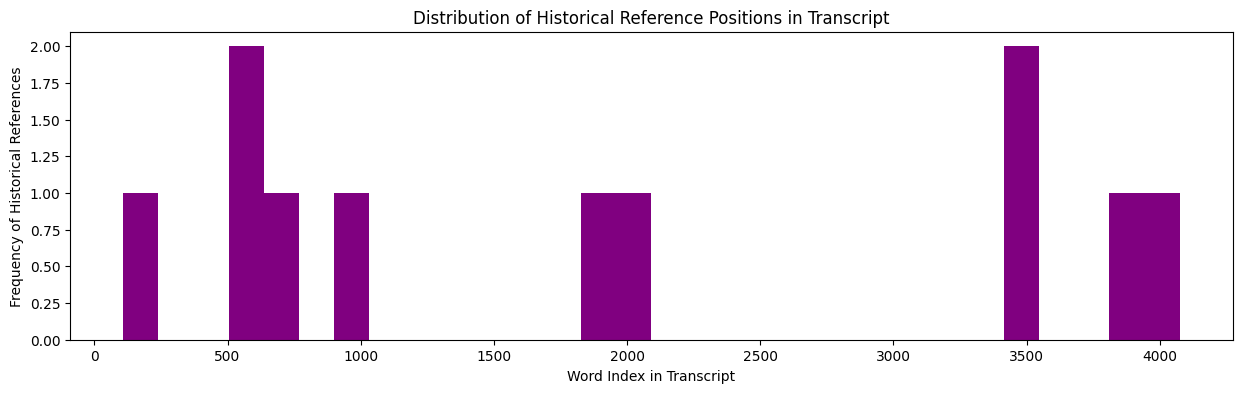

In [246]:

def analyze_historical_clusters(lines, window=5):
    text = " ".join(lines)
    words = text.split()
    
    date_contexts = []
    # Find all years and their index in the word list
    for i, word in enumerate(words):
        if re.match(r'\b(1\d{3}|20\d{2})\b', word):
            # Extract surrounding context
            start = max(0, i - window)
            end = min(len(words), i + window + 1)
            context = " ".join(words[start:end])
            date_contexts.append((word, i, context))

    # Identify Clusters: Group dates by their position in the transcript
    # (e.g., if many dates appear between word 500 and 1000)
    positions = [item[1] for item in date_contexts]
    
    print(f"Total Historical References: {len(date_contexts)}")
    print("\n--- Sample Date Contexts (Entity Detection) ---")
    for date, pos, ctx in date_contexts[:10]:
        print(f"Year {date} at position {pos}: \"...{ctx}...\"")
        
    return positions

# Run the analysis
date_positions = analyze_historical_clusters(transcript_no_ts_lines)
# graph the positions to see if they cluster
plt.figure(figsize=(15, 4))
plt.hist(date_positions, bins=30, color='purple')
plt.title('Distribution of Historical Reference Positions in Transcript')
plt.xlabel('Word Index in Transcript')
plt.ylabel('Frequency of Historical References')
plt.show()

In [247]:
# 1. NOISE DETECTION: Counting Stutters and Hesitations
def detect_noise(lines):
    # Pattern for stuttering (e.g., "الـ... الساموراي") or repeated punctuation
    stutter_pattern = r'\b(\w+)\.\.\.' 
    hesitations = [re.findall(stutter_pattern, line) for line in lines]
    flat_hesitations = [item for sublist in hesitations if sublist for item in sublist]
    # Matches any character repeated 3 or more times
    elongation_pattern = r'\b\w*([^\d\s\W])\1{2,}\w*\b'
    elongated_words = [re.findall(elongation_pattern, line) for line in lines]
    flat_elongated = [item for sublist in elongated_words if sublist for item in sublist]

    kashida_pattern = r'\w+ـ+\w+'
    kashidas = [re.findall(kashida_pattern, line) for line in lines]
    flat_kashidas = [item for sublist in kashidas if sublist for item in sublist]
    
    # Pattern for excessive punctuation (!!! or ؟؟؟)
    excl_pattern = r'!{2,}|؟{2,}'
    excessive_punct = [re.findall(excl_pattern, line) for line in lines]
    flat_punct = [item for sublist in excessive_punct if sublist for item in sublist]
    
    print(f"--- Noise Analysis ---")
    print(f"Total Stutters Found: {len(flat_hesitations)}")
    print(f"Top 3 Stuttered Words: {Counter(flat_hesitations).most_common(3)}")
    print(f"Total Elongated Words Found: {len(flat_elongated)}")
    print(f"Top 3 Elongated Characters: {Counter(flat_elongated).most_common(3)}")
    print(f"Total Kashida Instances: {len(flat_kashidas)}")
    print(f"Top 3 Kashida Words: {Counter(flat_kashidas).most_common(3)}")
    print(f"Instances of Repeated Punctuation: {len(flat_punct)}\n")

# 2. LINGUISTIC DISTRIBUTION: MSA vs. Egyptian Dialect Indicators
def analyze_dialect_markers(lines):
    # Common Egyptian markers (e.g., 'مش', 'ده', 'اللي', 'يا باشا')
    eg_markers = ['مش', 'ده', 'دي', 'اللي', 'عشان', 'برضه', 'كده']
    # Common MSA markers (e.g., 'ليس', 'هذا', 'الذي', 'لكي')
    msa_markers = ['ليس', 'هذا', 'هذه', 'الذي', 'التي', 'سوف', 'لن']
    
    text = " ".join(lines)
    words = text.split()
    
    eg_count = sum(1 for w in words if w in eg_markers)
    msa_count = sum(1 for w in words if w in msa_markers)
    
    print(f"--- Dialect Distribution (Sample Markers) ---")
    print(f"Total Words: {len(words)}")
    print(f"Egyptian Marker Count: {eg_count}")
    print(f"MSA Marker Count: {msa_count}")
    print(f"Ratio (EG/MSA): {eg_count/msa_count:.2f}" if msa_count > 0 else "N/A")

# 3. Frequency of code-switching (Arabic-English)
def analyze_code_switching(lines):
    text = " ".join(lines)
    words = text.split()
    arabic_count = sum(1 for w in words if re.search(r'[\u0600-\u06FF]', w))
    english_count = sum(1 for w in words if re.search(r'[A-Za-z]', w))
    
    print(f"--- Code-Switching Analysis ---")
    print(f"Total Words: {len(words)}")
    print(f"Arabic Words: {arabic_count}")
    print(f"English Words: {english_count}")
    print(f"Ratio (Arabic/English): {arabic_count/english_count:.2f}" if english_count > 0 else "N/A")
# RUNNING THE ANALYSIS
# Use the 'transcript_no_ts_lines' from your previous step
detect_noise(transcript_no_ts_lines)
analyze_dialect_markers(transcript_no_ts_lines)
analyze_code_switching(transcript_no_ts_lines)

--- Noise Analysis ---
Total Stutters Found: 11
Top 3 Stuttered Words: [('ربما', 2), ('ببعيدة', 1), ('الطفل', 1)]
Total Elongated Words Found: 0
Top 3 Elongated Characters: []
Total Kashida Instances: 31
Top 3 Kashida Words: [('الـSeppuku', 4), ('الـ47', 4), ('بالـSeppuku', 3)]
Instances of Repeated Punctuation: 0

--- Dialect Distribution (Sample Markers) ---
Total Words: 4628
Egyptian Marker Count: 135
MSA Marker Count: 20
Ratio (EG/MSA): 6.75
--- Code-Switching Analysis ---
Total Words: 4628
Arabic Words: 4595
English Words: 44
Ratio (Arabic/English): 104.43


In [222]:
from difflib import SequenceMatcher

def find_entity_variations(text_lines, threshold=0.8):
    # Extract unique words (excluding very short ones)
    words = set(re.findall(r'\b\w{4,}\b', " ".join(text_lines)))
    variations = []
    
    word_list = list(words)
    for i in range(len(word_list)):
        for j in range(i + 1, len(word_list)):
            w1, w2 = word_list[i], word_list[j]
            # Check similarity ratio
            ratio = SequenceMatcher(None, w1, w2).ratio()
            if ratio > threshold and ratio < 1.0:
                variations.append((w1, w2, ratio))
                
    return sorted(variations, key=lambda x: x[2], reverse=True)

# Run on your transcript
potential_variants = find_entity_variations(transcript_no_ts_lines)
print("Potential Named Entity Variations:")
for v in potential_variants[:20]:
    print(f"'{v[0]}' vs '{v[1]}' (Similarity: {v[2]:.2f})")

Potential Named Entity Variations:
'الإمبراطورية' vs 'لإمبراطورية' (Similarity: 0.96)
'إمبراطورية' vs 'لإمبراطورية' (Similarity: 0.95)
'إمبراطورية' vs 'كإمبراطورية' (Similarity: 0.95)
'الأوروبين' vs 'الأوروبيين' (Similarity: 0.95)
'بالمحاربين' vs 'المحاربين' (Similarity: 0.95)
'المعنويات' vs 'بالمعنويات' (Similarity: 0.95)
'ديبلوماسي' vs 'ديبلوماسية' (Similarity: 0.95)
'السويديين' vs 'والسويديين' (Similarity: 0.95)
'بالـGerman' vs 'الـGerman' (Similarity: 0.95)
'والجغرافيا' vs 'الجغرافيا' (Similarity: 0.95)
'الأوروبين' vs 'الأوروبي' (Similarity: 0.94)
'المناخية' vs 'والمناخية' (Similarity: 0.94)
'كإمبراطور' vs 'إمبراطور' (Similarity: 0.94)
'الأوروبية' vs 'الأوروبي' (Similarity: 0.94)
'الجغرافي' vs 'الجغرافية' (Similarity: 0.94)
'الجغرافي' vs 'الجغرافيا' (Similarity: 0.94)
'وإمبراطور' vs 'إمبراطور' (Similarity: 0.94)
'الخيانة' vs 'بالخيانة' (Similarity: 0.93)
'الحقيقية' vs 'الحقيقة' (Similarity: 0.93)
'الحقيقية' vs 'الحقيقي' (Similarity: 0.93)


In [ ]:

AR_PUNCT_MAP = {
    ",": "،",  # Western comma to Arabic comma
    ";": "؛",  # Western semicolon to Arabic semicolon
    "?": "؟",  # Western question mark to Arabic question mark
    "\"": "«", # Double quotes to Arabic guillemets (standard in formal text)
    "'": "’",  # Simple apostrophe to Arabic right single quote
    "“": "«",  # Western curly opening to Arabic
    "”": "»",  # Western curly closing to Arabic
}

# Create a regex pattern from the dictionary keys
PUNCT_RE = re.compile("|".join(re.escape(k) for k in AR_PUNCT_MAP.keys()))

def normalize_punct_and_space(text: str) -> str:
    # 1. Map punctuation using the regex pattern + lambda
    text = PUNCT_RE.sub(lambda m: AR_PUNCT_MAP[m.group(0)], text)
    
    # 2. Handle CSV escaped quotes (optional: changes "" to ")
    text = text.replace('""', '"')

    # 3. Normalize ellipsis
    text = re.sub(r"\.{2,}", "...", text)

    # 4. Remove weird spacing and invisible characters
    # \s also catches tabs and newlines
    text = re.sub(r"\s+", " ", text).strip()
    # 5. remove any remaining non-printable characters
    text = re.sub(r'[^\x20-\x7E\u0600-\u06FF]+', '', text)

    return text

transcript_punct_lines = [normalize_punct_and_space(l) for l in transcript_no_ts_lines]
print(transcript_punct_lines[:5])

['أرجوك يا جلالة المَلِك،', 'أرجوك، ارحمني!', 'أرحمك؟!', 'دا أنا هعمل منك عِبرة،', 'يا خاين يا عميل!']


In [195]:
# Arabic diacritics (tashkeel) + tatweel
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u0640]")  # includes tatweel

def normalize_arabic(text: str) -> str:
    # remove diacritics/tatweel
    text = re.sub(DIACRITICS_RE, "", text)

    # normalize hamza/alef forms to bare alef
    text = re.sub(r"[إأآٱ]", "ا", text)

    # normalize ya/alef maqsura
    text = text.replace("ى", "ي")

    # normalize ta marbuta (choose ONE policy; this one maps ة→ه)
    text = text.replace("ة", "ه")

    # normalize waw/ya hamza to base letters (optional but helps consistency)
    text = text.replace("ؤ", "و").replace("ئ", "ي")
    text = re.sub(r'\s+', ' ', text).strip()

    return text

transcript_norm1_lines = [normalize_arabic(l) for l in transcript_punct_lines]
print(transcript_norm1_lines[:5])

['ارجوك يا جلاله الملك،', 'ارجوك، ارحمني!', 'ارحمك؟!', 'دا انا هعمل منك عبره،', 'يا خاين يا عميل!']


In [196]:

def clean_stutters_and_noise(text):
    # 1. Remove stutters (e.g., "السامو... الساموراي" -> "السامو الساموراي")
    text = re.sub(r'\b(\w+)\.\.\.\s+\1\b', r'\1', text)
    # very common in transcribed audio where a speaker hesitates.

    # 2. Reduce repeated punctuation (e.g., !!! -> ! or ؟؟؟ -> ؟)
    text = re.sub(r'!{2,}', '!', text)
    text = re.sub(r'؟{2,}', '؟', text)
    # Remove Kashida (ـ) which is used for elongation in Arabic but can be noise for NLP
    text = re.sub(r'ـ+', '', text)
    
    # 3. Handle Punctuation Spacing (Isolate from words)
    # This ensures "الساموراي!" becomes "الساموراي !"
    text = re.sub(r'([،؟!.()"-])', r' \1 ', text)
    # 4. Normalize Elongations (e.g., "جمييييل" -> "جمييل")

    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r'\s+', ' ', text).strip()

# In Machine Learning (NLP), "الساموراي" and "الساموراي!" are seen as two different words. By adding spaces, the computer can treat the word and the punctuation as two separate "tokens."
    
    return text
transcript_cleaned_lines = [clean_stutters_and_noise(l) for l in transcript_norm1_lines]
print(transcript_cleaned_lines[:20])


['ارجوك يا جلاله الملك ،', 'ارجوك ، ارحمني !', 'ارحمك ؟ !', 'دا انا هعمل منك عبره ،', 'يا خاين يا عميل !', 'ارجوك !', 'كله الا النفي ،', 'كله الا النفي ،', 'مش عايز اتنفي .', 'تتنفي ؟ !', 'طب ايه رايك بقي ،', 'اني هنفيك انت وعيلتك كلها !', 'ايه دا ؟ !', '- هو ينفع عيلتي تيجي ؟ !', '- ايه ؟ !', 'قصدي ، لا ، ارجوك ،', 'ارجوك ، ما تنفنيش انا وعيلتي', 'في جزيره تكون استواييه وجوها كويس كدا !', 'ما تعيشنيش في كابوس زي دا ، لا !', 'بقي كدا ؟ !']


In [197]:
# removee extra spaces around latin words to avoid merging them with Arabic
def normalize_english_case(text: str) -> str:
    # lower-case latin sequences only
    text = re.sub(r'الـ\s*', 'ال ', text)
    text = re.sub(r'([\u0600-\u06FF])([A-Za-z])', r'\1 \2', text)
    text = re.sub(r'([A-Za-z])([\u0600-\u06FF])', r'\1 \2', text)
    # Remove common Arabic prefixes (و, ب, ف) when they are attached to long words (4+ chars) to avoid merging them with English words
    # however aggressive stemming, as it may strip away the dialectal markers
    text = re.sub(r'\b[وبف](?=\w{4,})', '', text)
    # This ensures "الساموراي!" becomes "الساموراي !"
    def lower_latin(m):
        return m.group(0).lower()
    return re.sub(r"[A-Za-z]+", lower_latin, text)
    



transcript_norm2_lines = [normalize_english_case(l) for l in transcript_cleaned_lines]
print(transcript_norm2_lines[:20])

['ارجوك يا جلاله الملك ،', 'ارجوك ، ارحمني !', 'ارحمك ؟ !', 'دا انا هعمل منك عبره ،', 'يا خاين يا عميل !', 'ارجوك !', 'كله الا النفي ،', 'كله الا النفي ،', 'مش عايز اتنفي .', 'تتنفي ؟ !', 'طب ايه رايك بقي ،', 'اني هنفيك انت عيلتك كلها !', 'ايه دا ؟ !', '- هو ينفع عيلتي تيجي ؟ !', '- ايه ؟ !', 'قصدي ، لا ، ارجوك ،', 'ارجوك ، ما تنفنيش انا عيلتي', 'في جزيره تكون استواييه جوها كويس كدا !', 'ما تعيشنيش في كابوس زي دا ، لا !', 'بقي كدا ؟ !']


In [198]:
def check_collisions(original_lines, cleaned_lines):
    orig_vocab = set(" ".join(original_lines).split())
    clean_vocab = set(" ".join(cleaned_lines).split())
    
    print(f"Original Vocab Size: {len(orig_vocab)}")
    print(f"Cleaned Vocab Size: {len(clean_vocab)}")
    print(f"Reduction: {len(orig_vocab) - len(clean_vocab)} words merged.")

check_collisions(transcript_no_ts_lines, transcript_norm2_lines)



Original Vocab Size: 3997
Cleaned Vocab Size: 3145
Reduction: 852 words merged.


In [199]:
# detect noise on cleaned lines
detect_noise(transcript_norm2_lines)
potential_variants_after = find_entity_variations(transcript_norm2_lines)
print("Potential Named Entity Variations:")
for v in potential_variants_after[:20]:
    print(f"'{v[0]}' vs '{v[1]}' (Similarity: {v[2]:.2f})")


--- Noise Analysis ---
Total Stutters Found: 0
Top 3 Stuttered Words: []
Total Elongated Words Found: 0
Top 3 Elongated Characters: []
Total Kashida Instances: 0
Top 3 Kashida Words: []
Instances of Repeated Punctuation: 0

Potential Named Entity Variations:
'لامبراطوريه' vs 'الامبراطوريه' (Similarity: 0.96)
'امبراطوريته' vs 'امبراطوريه' (Similarity: 0.95)
'لامبراطوريه' vs 'امبراطوريه' (Similarity: 0.95)
'كامبراطوريه' vs 'امبراطوريه' (Similarity: 0.95)
'ديبلوماسيه' vs 'ديبلوماسي' (Similarity: 0.95)
'الاوروبين' vs 'الاوروبيين' (Similarity: 0.95)
'كامبراطور' vs 'امبراطور' (Similarity: 0.94)
'الاوروبيه' vs 'الاوروبي' (Similarity: 0.94)
'الاوروبي' vs 'الاوروبين' (Similarity: 0.94)
'الجغرافي' vs 'الجغرافيا' (Similarity: 0.94)
'الجغرافي' vs 'الجغرافيه' (Similarity: 0.94)
'السياسيه' vs 'السياسه' (Similarity: 0.93)
'الحقيقه' vs 'الحقيقيه' (Similarity: 0.93)
'الحقيقيه' vs 'الحقيقي' (Similarity: 0.93)
'المناسب' vs 'المناسبه' (Similarity: 0.93)
'البحريه' vs 'البحري' (Similarity: 0.92)
'لاليكسي' v

In [200]:
def universal_normalize(text):
    """Applies your existing normalization pipeline to any input string."""
    if not isinstance(text, str): return ""
    # 1. Standardize Punctuation
    text = normalize_punct_and_space(text)
    # 2. Arabic Orthography (Alif, Ya, Ta Marbuta, etc.)
    text = normalize_arabic(text)
    # 3. Handle Repeats and Noise
    text = clean_stutters_and_noise(text)
    # 4. English Case and Spacing
    text = normalize_english_case(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.strip()

# Join all cleaned transcript lines into one searchable block
full_transcript_text = " ".join(transcript_norm2_lines) 

# Apply normalization to the QA dataframe
qa['normalized_answer'] = qa['answer'].apply(universal_normalize)

# Check for mismatches
qa['found_in_transcript'] = qa['normalized_answer'].apply(lambda x: x in full_transcript_text)
mismatches = qa[qa['found_in_transcript'] == False]

print(f"Total QA Pairs: {len(qa)}")
print(f"Successfully Aligned: {len(qa) - len(mismatches)}")
print(f"Mismatches Found: {len(mismatches)}")

if not mismatches.empty:
    print("\nSample Mismatch (Original vs Normalized):")
    print(mismatches[['answer', 'normalized_answer']].head())



Total QA Pairs: 300
Successfully Aligned: 300
Mismatches Found: 0


In [212]:
import os
import pandas as pd
from pathlib import Path

# Define paths (Update these to your local paths)
TRANSCRIPT_DIR = Path("/Users/nourahmed/Arabic-NLP-System/Transcripts/")
QA_DIR = Path("/Users/nourahmed/Arabic-NLP-System/QA/")
OUTPUT_DIR = Path("./Model_Ready_Data/")
OUTPUT_DIR.mkdir(exist_ok=True)

# List to store global stats
global_stats = []
all_qa_data = []

def process_pipeline():
    # 1. Map CSVs to TXT files (Handling the naming mismatch we found earlier)
    # We'll use a mapping or search based on common keywords
    for qa_file in QA_DIR.glob("*.csv"):
        video_id = qa_file.stem.split('_')[0]
        
        # Load QA
        df_qa = pd.read_csv(qa_file)
        
    
        transcript_filename = "الساموراي  الدحيح.txt" if "3AwL93uolIA" in qa_file.name else None
        transcript_filename = "الأخطبوط  الدحيح.txt" if "8rcY34IA-6I" in qa_file.name else transcript_filename
        transcript_filename = "كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.txt" if "z2NGnjXG5uQ" in qa_file.name else transcript_filename
        transcript_filename = "مصير الأرض و الشمس و كل شيء  الدحيح.txt" if "0urc3PabvOs" in qa_file.name else transcript_filename
        transcript_filename = "كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح.txt" if "8ZL2AAxQmLQ" in qa_file.name else transcript_filename
        transcript_filename = "هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح.txt" if "ArytJ_HZ-1E" in qa_file.name else transcript_filename
 
        if not transcript_filename:
            continue
            
        txt_path = TRANSCRIPT_DIR / transcript_filename
        
        with open(txt_path, "r", encoding="utf-8") as f:
            raw_lines = f.readlines()

        # 2. Clean Transcript
        # Strip timestamps, normalize, and segment
        clean_lines = [strip_timestamp(l) for l in raw_lines if strip_timestamp(l)]
        normalized_lines = [universal_normalize(l) for l in clean_lines]
        full_text = " ".join(normalized_lines)
        
        # 3. Clean and Align QA
        df_qa['normalized_answer'] = df_qa['answer'].apply(universal_normalize)
        df_qa['normalized_question'] = df_qa['question'].apply(universal_normalize)
        df_qa['is_aligned'] = df_qa['normalized_answer'].apply(lambda x: x in full_text)
        
        # 4. Store Stats
        global_stats.append({
            "video_id": video_id,
            "tokens": len(full_text.split()),
            "alignment_rate": df_qa['is_aligned'].mean() * 100
        })
        
        all_qa_data.append(df_qa)
        
        # Save processed version of this specific video
        df_qa.to_csv(OUTPUT_DIR / f"{video_id}_cleaned.csv", index=False)
        with open(OUTPUT_DIR / f"{video_id}_transcript.txt", "w", encoding="utf-8") as f:
            f.write(full_text)

    print("--- Milestone 1 Processing Complete ---")
    return pd.DataFrame(global_stats)

stats_summary = process_pipeline()
print(stats_summary)

--- Milestone 1 Processing Complete ---
      video_id  tokens  alignment_rate
0  3AwL93uolIA    5837           100.0
1  8ZL2AAxQmLQ    7022           100.0
2  8rcY34IA-6I    6919           100.0
3        ArytJ    6173           100.0
4  z2NGnjXG5uQ   10313           100.0
5  0urc3PabvOs    5998           100.0


In [ ]:
def unify_entities(lines, variations, threshold=0.9):
    """
    Takes the output from find_entity_variations and replaces 
    the 'variant' with the 'primary' word in the text.
    """
    unified_lines = []
    # Create a mapping of variant -> primary
    mapping = {v[1]: v[0] for v in variations if v[2] >= threshold}
    
    for line in lines:
        words = line.split()
        new_words = [mapping.get(w, w) for w in words]
        unified_lines.append(" ".join(new_words))
    
    print(f"Unified {len(mapping)} distinct entity variations.")
    return unified_lines

# Apply to your cleaned lines
transcript_unified_lines = unify_entities(transcript_norm2_lines, potential_variants)
print(transcript_unified_lines[:20])    

Unified 208 distinct entity variations.

Sample Unified Lines:
ارجوك يا جلاله الملك ،
ارجوك ، ارحمني !
ارحمك ؟ !
دا انا هعمل منك عبره ،
يا خاين يا عميل !
ارجوك !
كله الا النفي ،
كله الا النفي ،
مش عايز اتنفي .
تتنفي ؟ !
طب ايه رايك بقي ،
اني هنفيك انت عيلتك كلها !
ايه دا ؟ !
- هو ينفع عيلتي تيجي ؟ !
- ايه ؟ !
قصدي ، لا ، ارجوك ،
ارجوك ، ما تنفنيش انا عيلتي
في جزيره تكون استواييه جوها كويس كدا !
ما تعيشنيش في كابوس زي دا ، لا !
بقي كدا ؟ !


In [ ]:
def detect_topic_shifts(lines, keywords=['عزيزي المشاهد', 'حلقة جديدة', 'تعالى نفتح', 'نرجع لـ']):
    shifts = []
    for i, line in enumerate(lines):
        if any(key in line for key in keywords):
            shifts.append((i, line))
    
    print(f"Detected {len(shifts)} potential topic shifts.")
    for line_idx, content in shifts:
        print(f"Shift at Line {line_idx}: {content[:50]}...")
    return shifts
topic_shifts = detect_topic_shifts(transcript_norm2_lines)

In [217]:
def create_model_chunks(transcript_text, chunk_size=500, overlap=50):
    """Splits transcript into overlapping chunks of word counts."""
    words = transcript_text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = " ".join(words[i : i + chunk_size])
        chunks.append(chunk)
    return chunks

# Example usage
final_transcript_string = " ".join(transcript_unified_lines)
data_chunks = create_model_chunks(final_transcript_string)
print(f"Created {len(data_chunks)} chunks for the modeling phase.")

Created 23 chunks for the modeling phase.
